<a href="https://colab.research.google.com/github/sakshi10-AI/Sakshi-Bansod-Task-2/blob/main/Sakshi_Bansod_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
df = pd.read_csv('/content/Unemployment_Rate_upto_11_2020.csv')

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [ ]:
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (267, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [ ]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Region.1,0
longitude,0
latitude,0


In [ ]:
df.columns = [
    'Region',
    'Date',
    'Frequency',
    'Unemployment_Rate',
    'Employed',
    'Labour_Participation_Rate',
    'Region_Group',
    'Longitude',
    'Latitude'
]

df.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Region_Group,Longitude,Latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

df.head()

/tmp/ipykernel_890/4004979637.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Region_Group,Longitude,Latitude,Month,Year
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74,1,2020
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74,2,2020
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74,3,2020
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74,4,2020
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74,5,2020


In [ ]:
df.describe()

,Date,Unemployment_Rate,Employed,Labour_Participation_Rate,Longitude,Latitude,Month,Year
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000,267.000000,267.0
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425,5.535581,2020.0
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400,1.000000,2020.0
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600,3.000000,2020.0
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300,6.000000,2020.0
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900,8.000000,2020.0
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600,10.000000,2020.0
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738,2.870915,0.0


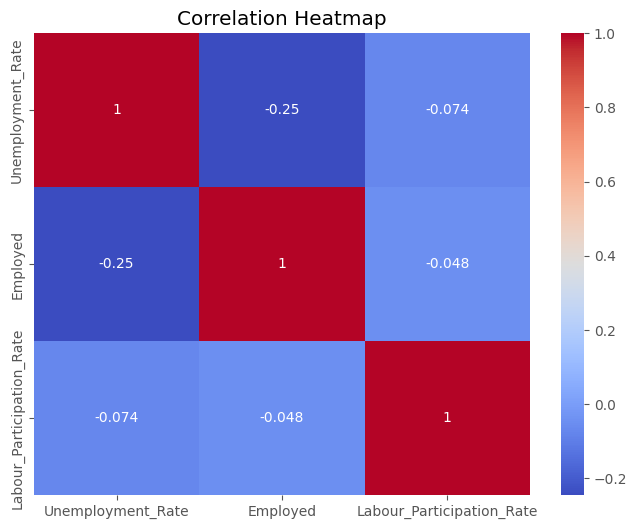

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Unemployment_Rate',
        'Employed',
        'Labour_Participation_Rate']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

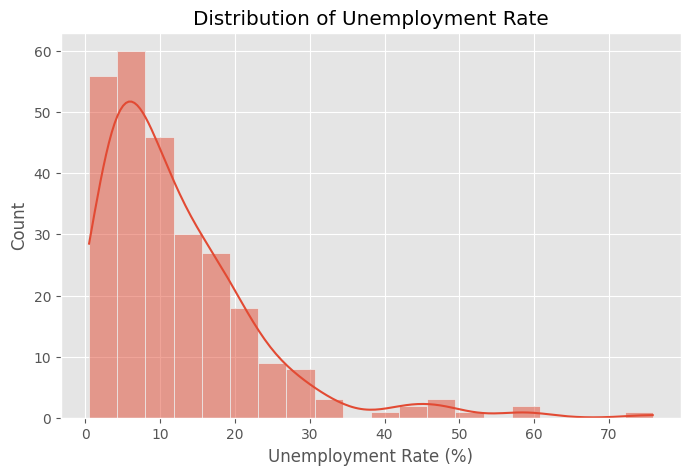

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Unemployment_Rate'],
    bins=20,
    kde=True
)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.show()

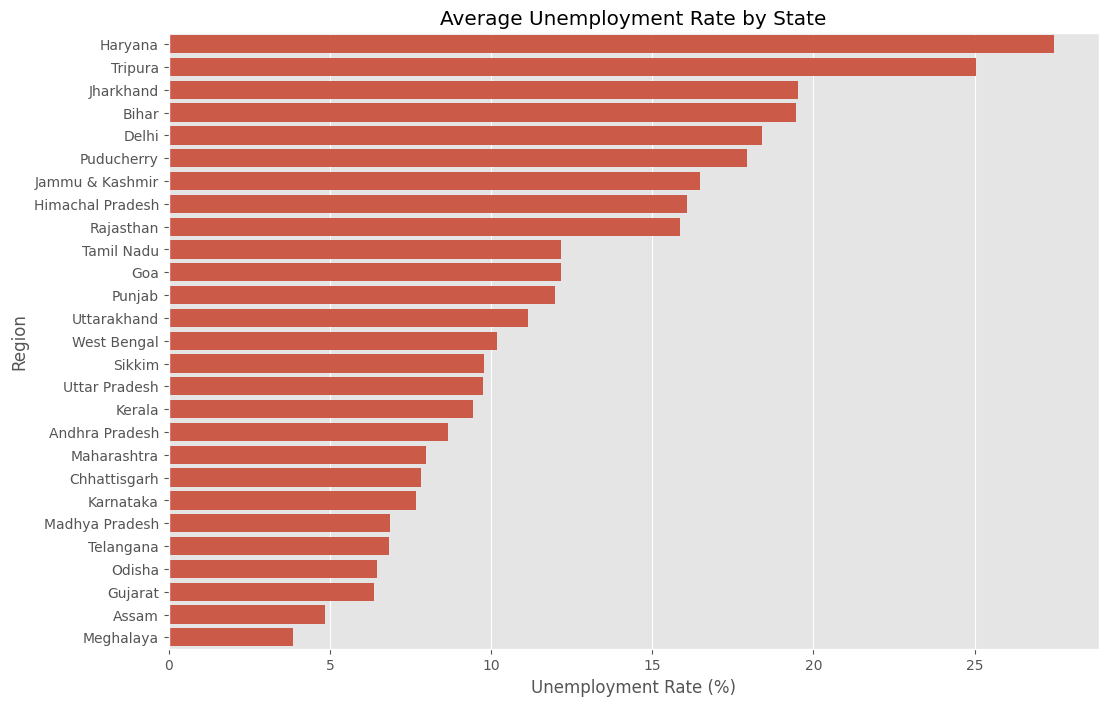

In [ ]:
state_unemployment = df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,8))

sns.barplot(
    x=state_unemployment.values,
    y=state_unemployment.index
)

plt.title("Average Unemployment Rate by State")
plt.xlabel("Unemployment Rate (%)")
plt.show()

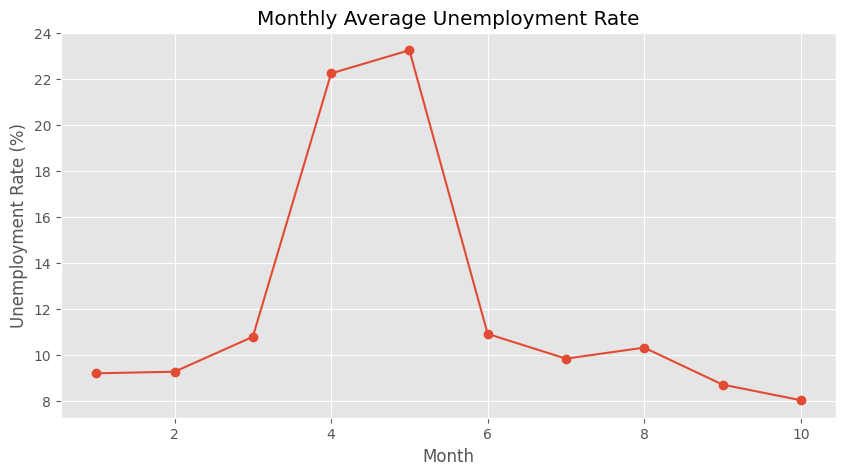

In [ ]:
monthly = df.groupby('Month')['Unemployment_Rate'].mean()

plt.figure(figsize=(10,5))

plt.plot(monthly.index, monthly.values, marker='o')

plt.title("Monthly Average Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)

plt.show()

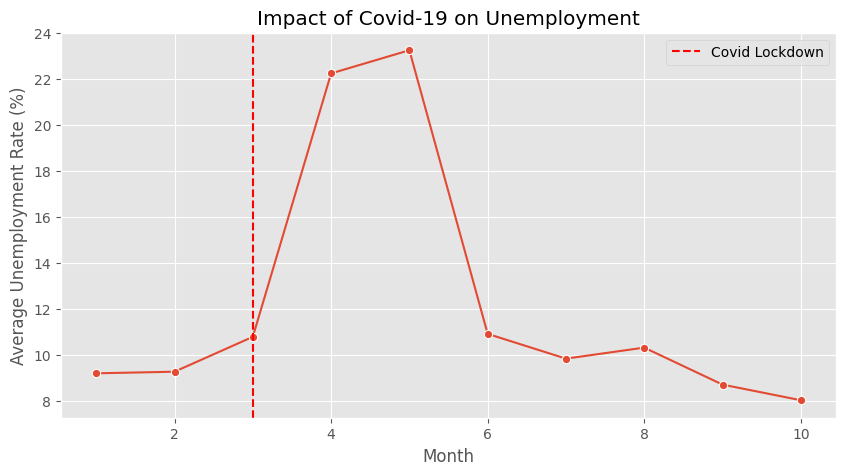

In [ ]:
covid_months = df.groupby('Month')['Unemployment_Rate'].mean()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=covid_months.index,
    y=covid_months.values,
    marker='o'
)

plt.axvline(x=3, color='red', linestyle='--', label='Covid Lockdown')

plt.title("Impact of Covid-19 on Unemployment")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.legend()

plt.show()

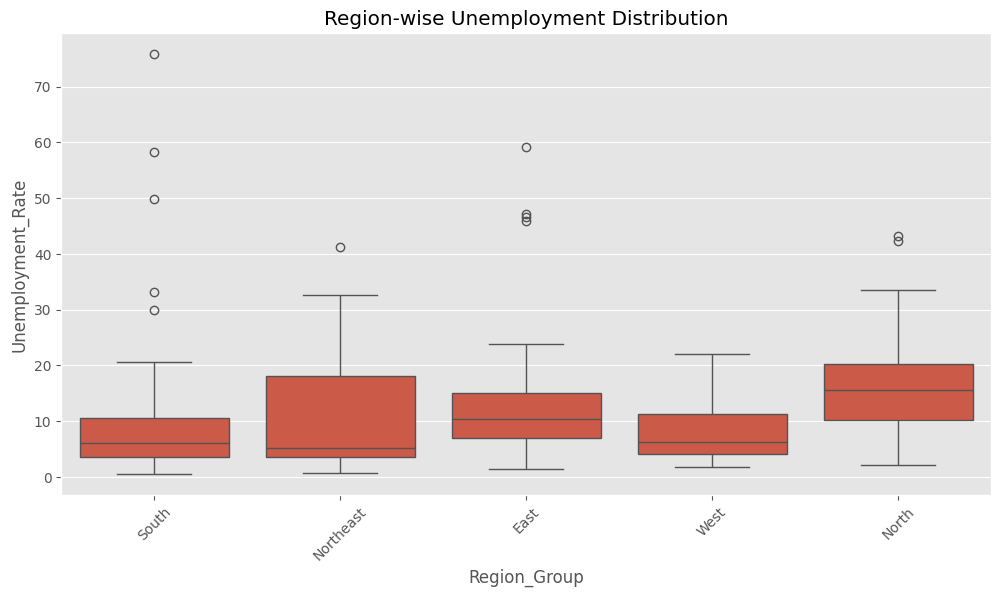

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Region_Group',
    y='Unemployment_Rate',
    data=df
)

plt.title("Region-wise Unemployment Distribution")
plt.xticks(rotation=45)

plt.show()

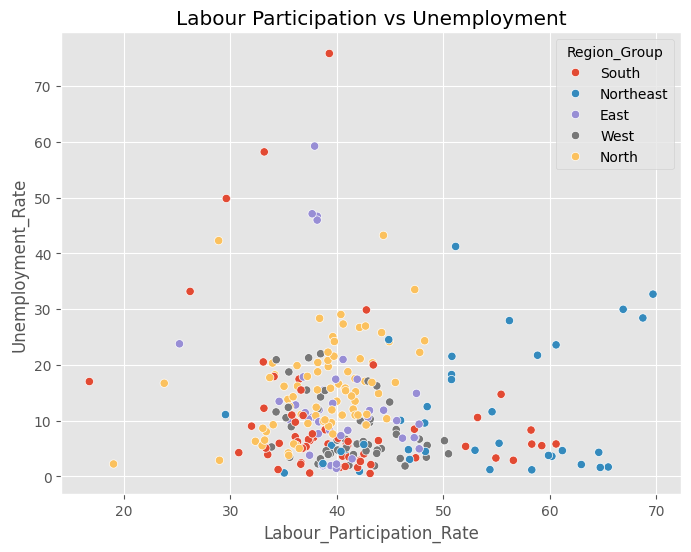

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Labour_Participation_Rate',
    y='Unemployment_Rate',
    hue='Region_Group',
    data=df
)

plt.title("Labour Participation vs Unemployment")
plt.show()